**Step 1. Import libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    ReLU,
    AveragePooling2D,
    Flatten,
    Dense
)
import matplotlib.pyplot as plt

**Step 2. Load the CIFAR-10 dataset**

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1880s 11us/step
(50000, 32, 32, 3)
(50000, 1)


**Step 3. Normalize the images**

Pixel values range from 0–255.

Normalize to 0–1.

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

**Step 4. Visualize some images**

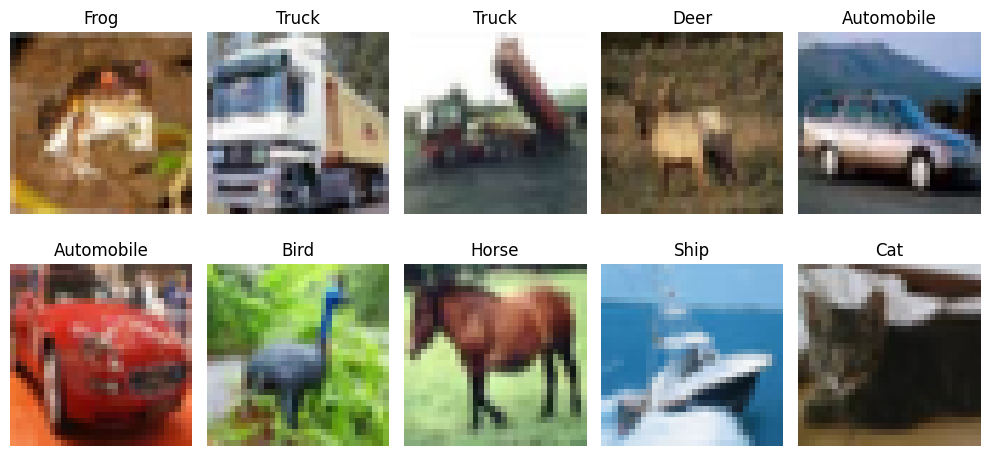

In [4]:
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 5. Build a minimal CNN**

In [5]:
model = Sequential([

    Input(shape=(32,32,3)),

    Conv2D(
        filters=8,
        kernel_size=(3,3),
        padding="same"
    ),

    ReLU(),

    AveragePooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(32, activation="relu"),

    Dense(10, activation="softmax")

])

**Step 6. Compile the model**

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Step 7. Display the architecture**

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,122 (258.29 KB)

 Trainable params: 66,122 (258.29 KB)

 Non-trainable params: 0 (0.00 B)

**Step 8. Train**

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.3576 - loss: 1.7740 - val_accuracy: 0.4140 - val_loss: 1.6306
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.4658 - loss: 1.4856 - val_accuracy: 0.4750 - val_loss: 1.4660
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.4997 - loss: 1.4015 - val_accuracy: 0.4998 - val_loss: 1.4103
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5153 - loss: 1.3534 - val_accuracy: 0.5083 - val_loss: 1.3825
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5295 - loss: 1.3193 - val_accuracy: 0.5155 - val_loss: 1.3803
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5398 - loss: 1.2929 - val_accuracy: 0.5304 - val_loss: 1.3392
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.5472 - loss: 1.2696 - val_accuracy: 0.5295 - val_loss: 1.3411
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.5553 -

**Step 9. Evaluate**

In [9]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print(f"Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5408 - loss: 1.2931
Accuracy: 0.5408


**Step 10. Plot the learning process**

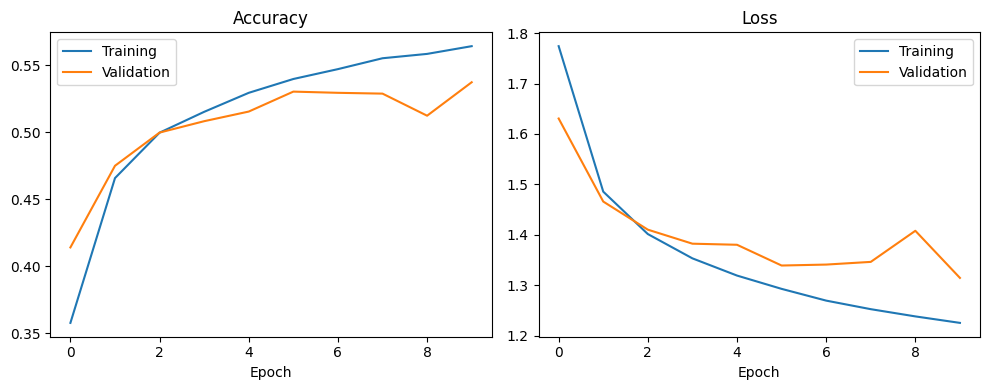

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# **PREDICTION**

**Step 1. Generate predictions**

In [11]:
import numpy as np

# Predict class probabilities
y_pred_prob = model.predict(x_test, verbose=0)

# Predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test.flatten()

**Step 2. Classification metrics**

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1  = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

Accuracy : 0.5408
Precision: 0.5377
Recall   : 0.5408
F1-score : 0.5356

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.56      0.58      1000
           1       0.67      0.69      0.68      1000
           2       0.48      0.28      0.36      1000
           3       0.36      0.39      0.38      1000
           4       0.47      0.41      0.44      1000
           5       0.47      0.48      0.47      1000
           6       0.53      0.60      0.57      1000
           7       0.59      0.64      0.61      1000
           8       0.63      0.73      0.68      1000
           9       0.57      0.61      0.59      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



**Step 3. Confusion matrix**

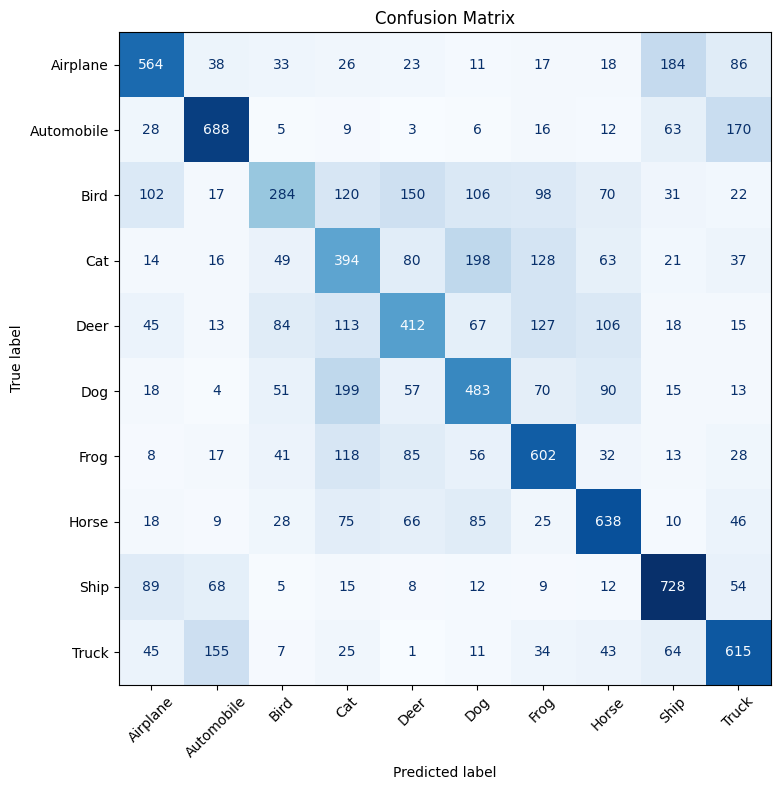

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Step 4. Visualize predictions**

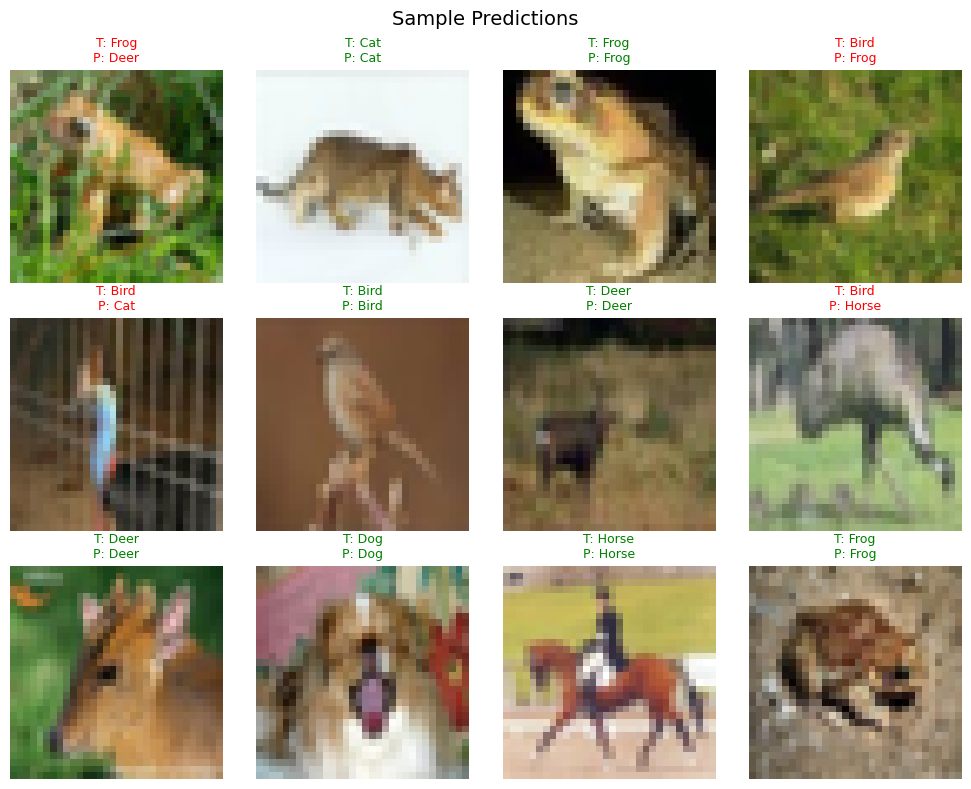

In [14]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(x_test), 12, replace=False)

fig, axes = plt.subplots(3,4, figsize=(10,8))

for ax, idx in zip(axes.flat, indices):

    ax.imshow(x_test[idx])

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    color = "green" if y_true[idx] == y_pred[idx] else "red"

    ax.set_title(
        f"T: {true_label}\nP: {pred_label}",
        fontsize=9,
        color=color
    )

    ax.axis("off")

plt.suptitle("Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

**Step 5. Show only misclassified images**

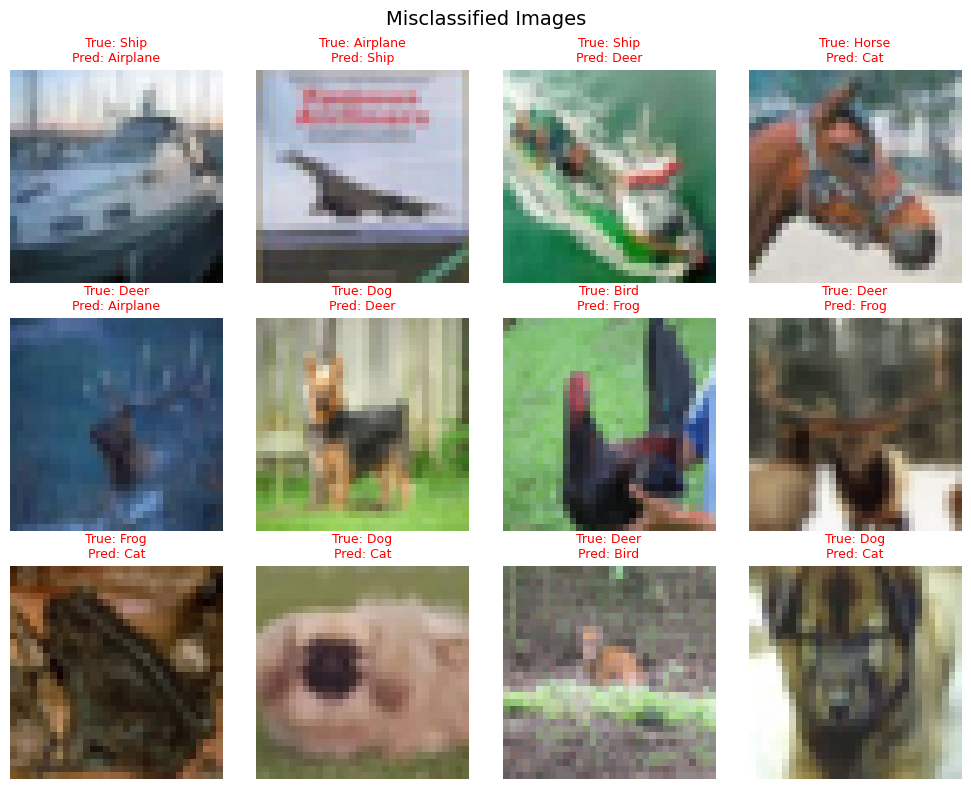

In [15]:
errors = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(3,4, figsize=(10,8))

for ax, idx in zip(axes.flat, errors[:12]):

    ax.imshow(x_test[idx])

    ax.set_title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}",
        color="red",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle("Misclassified Images", fontsize=14)
plt.tight_layout()
plt.show()